1. What is Logistic Regression?

    - Logistic regression is a supervised machine learning algorithm used for classification problems, not regression (despite the name).
    - It predicts categorical outcomes—usually binary (0 or 1, Yes or No, True or False).

Example:
    - Predict if a student passes (1) or fails (0) an exam based on hours studied.

2. Why not use Linear Regression?

    - Linear regression predicts continuous values.
    - If you try linear regression for a binary outcome, it may give values <0 or >1, which doesn’t make sense for probabilities.
    - Logistic regression solves this by using the sigmoid function to output probabilities between 0 and 1.

3. Sigmoid Function

    - The sigmoid function is a special mathematical function used in logistic regression to convert any number into a probability between 0 and 1.

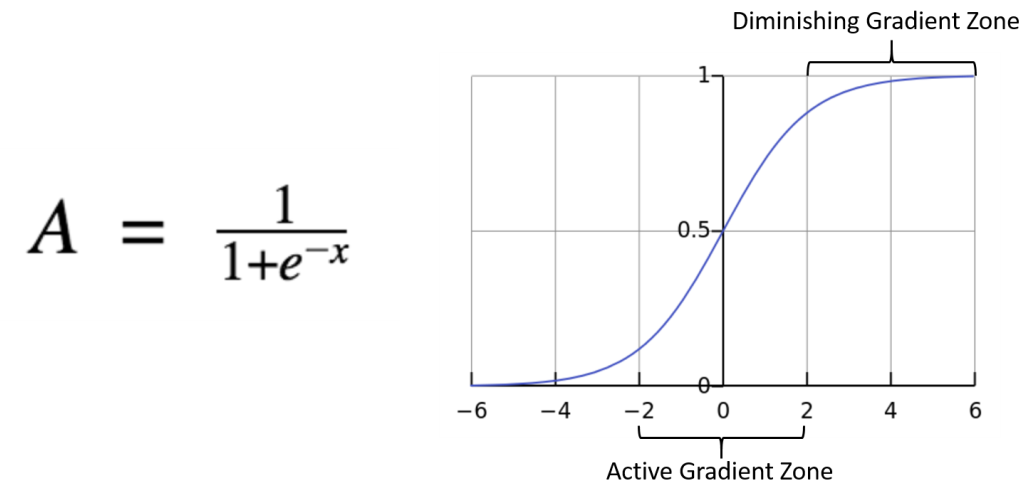


4. Decision Boundary

  - If probability ≥ 0.5 → predict 1
  - If probability < 0.5 → predict 0
  - Threshold can be adjusted depending on the problem.


5. Cost Function

   - Logistic regression uses log loss (cross-entropy loss) instead of mean squared error:
![cost function.png](<attachment:cost function.png>)


6. Advantages:

   - Easy to implement and interpret.
   - Gives probabilities.
   - Works well for linearly separable data.


7. Limitations:

   - Can’t handle complex nonlinear relationships without transformations.
   - Sensitive to outliers.


9. Variants:

   - Multinomial Logistic Regression: More than 2 classes.
   - Regularized Logistic Regression: Adds L1/L2 penalties to prevent overfitting.
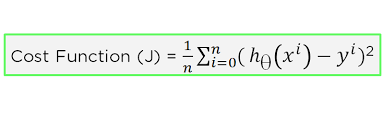

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("social_network.csv")
df

,UserID,Gender,Age,EstimatedSalary,Purchased
0,1,Male,19,19000,0
1,2,Male,35,20000,0
2,3,Female,26,43000,0
3,4,Female,27,57000,0
4,5,Male,19,76000,0
5,6,Female,27,58000,1
6,7,Male,27,84000,0
7,8,Female,32,150000,1
8,9,Female,25,33000,0
9,10,Male,35,65000,1


In [4]:
df.shape

(20, 5)

In [5]:
df.columns

Index(['UserID', 'Gender', 'Age', 'EstimatedSalary', 'Purchased'], dtype='object')

In [6]:
df.isnull().sum()

UserID             0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

In [7]:
# separate imput and output data

In [11]:
x = df[['Age', 'EstimatedSalary']]
y = df['Purchased']
x

,Age,EstimatedSalary
0,19,19000
1,35,20000
2,26,43000
3,27,57000
4,19,76000
5,27,58000
6,27,84000
7,32,150000
8,25,33000
9,35,65000


In [12]:
# chaeck for linearity

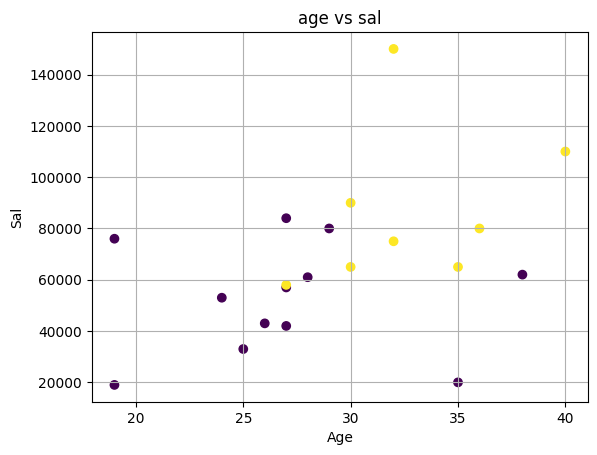

In [13]:
plt.title("age vs sal")
plt.xlabel('Age')
plt.ylabel("Sal")
plt.scatter(x['Age'], x['EstimatedSalary'], c = df['Purchased'])
plt.grid()

In [14]:
# cross validation

In [15]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, random_state = 0, test_size = 0.25)

In [16]:
x_train.shape, y_train.shape

((15, 2), (15,))

In [17]:
x_test.shape, y_test.shape

((5, 2), (5,))

In [18]:
x

,Age,EstimatedSalary
0,19,19000
1,35,20000
2,26,43000
3,27,57000
4,19,76000
5,27,58000
6,27,84000
7,32,150000
8,25,33000
9,35,65000


In [19]:
# Feature scaling -> normalization

In [22]:
from sklearn.preprocessing import MinMaxScaler
sca = MinMaxScaler()

In [23]:
x_train_scaled = sca.fit_transform(x_train)
y_test_scaled = sca.transform(x_test)

In [24]:
# build the model

In [25]:
from sklearn.linear_model import LogisticRegression

In [26]:
log = LogisticRegression()

In [34]:
log.fit(x_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [28]:
# evaluate

In [31]:
from sklearn.preprocessing import StandardScaler

# If not done yet
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)  # <-- This creates x_test_scaled

# Then you can predict
y_pred = log.predict(x_test_scaled)

In [32]:
y_pred

array([0, 0, 0, 0, 0])

In [35]:
# create a dataframe for actual and predicted

In [36]:
result = pd.DataFrame({
    "actual": y_test,
    "predicted": y_pred
})
result

,actual,predicted
18,1,0
1,0,0
19,1,0
8,0,0
10,0,0


In [39]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, accuracy_score


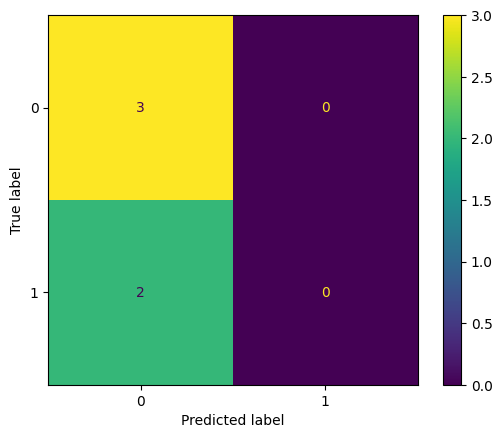

In [40]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

In [41]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.60      1.00      0.75         3
           1       0.00      0.00      0.00         2

    accuracy                           0.60         5
   macro avg       0.30      0.50      0.38         5
weighted avg       0.36      0.60      0.45         5



c:\INTERNSHIP\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\INTERNSHIP\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\INTERNSHIP\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [ ]:
recall = 67 / 68  # recall
# out of total 0 in the data how many model predicted
recall

0.9852941176470589

In [43]:
precision = 67 / 77  # precision
# out of 0 predicted by model how many are correct
precision


0.8701298701298701

In [44]:
(2 * recall * precision)/ (recall + precision)
# harmonic mean of precision and recall

0.9241379310344828

In [45]:
# actual accuracy
accuracy_score(y_test, y_pred)

0.6

In [46]:
# roc_auc

In [48]:
from sklearn.metrics import roc_auc_score, roc_curve

In [49]:
y_pred_prob = log.predict_proba(x_test_scaled)[:,1]

In [50]:
y_pred_prob

array([0.50899087, 0.22103253, 0.36802617, 0.09989344, 0.44727055])

In [51]:
auc = roc_auc_score(y_test, y_pred_prob)
auc

0.8333333333333334

In [52]:
roc_curve(y_test, y_pred_prob)

(array([0.        , 0.        , 0.33333333, 0.33333333, 1.        ]),
 array([0. , 0.5, 0.5, 1. , 1. ]),
 array([       inf, 0.50899087, 0.44727055, 0.36802617, 0.09989344]))

In [53]:
fpr, tpr, threshold = roc_curve(y_test, y_pred_prob)

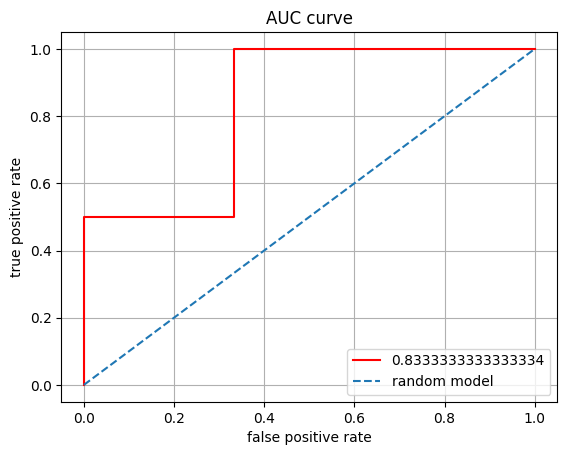

In [54]:
plt.title("AUC curve")
plt.xlabel('false positive rate')
plt.ylabel('true positive rate')
plt.plot(fpr, tpr, color = 'red', label = auc)
plt.plot([0,1], [0,1], label = 'random model', ls = '--')
plt.grid()
plt.legend()

In [55]:
# threshold tuning


In [56]:
log.predict_proba(x_test_scaled)

array([[0.49100913, 0.50899087],
       [0.77896747, 0.22103253],
       [0.63197383, 0.36802617],
       [0.90010656, 0.09989344],
       [0.55272945, 0.44727055]])

In [57]:
y_pred_prob

array([0.50899087, 0.22103253, 0.36802617, 0.09989344, 0.44727055])

In [58]:
threshold = 0.7
y_pred_new = (y_pred_prob > threshold).astype(int)

In [59]:
y_pred_new

array([0, 0, 0, 0, 0])